<a href="https://colab.research.google.com/github/Bhanuteja01-kolli/Wholesale_customers_Project/blob/main/Wholesale_customers_data_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# * 1)Data set Understanding*

In [ ]:
import pandas as pd
df=pd.read_csv("/content/Wholesale customers data.csv")
X=df[['Region','Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']]
y=df['Channel']


# **2) Data Quality and Preprocesing**

**i)detect missing and duplicate values**

In [ ]:
print(df.isnull().sum())
print(df.duplicated().sum())

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64
0


ii)	**Encode categorical variables such as Channel or Region.**

In [ ]:
df['Channel']=df['Channel'].astype('category').cat.codes
df['Region']=df['Region'].astype('category').cat.codes
print(df[['Channel','Region']])

     Channel  Region
0          1       2
1          1       2
2          1       2
3          0       2
4          1       2
..       ...     ...
435        0       2
436        0       2
437        1       2
438        0       2
439        0       2

[440 rows x 2 columns]


 iii)	Scale numerical features where required.

In [ ]:
from sklearn.preprocessing import StandardScaler
num_features = ['Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']
scaler=StandardScaler()
df[num_features]=scaler.fit_transform(df[num_features])
df.head()


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,1,2,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339
1,1,2,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151
2,1,2,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293
3,0,2,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411
4,1,2,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347


# **3) Exploratory Data Analysis (EDA)**

**i)	Compare spending patterns across different customer types.**

In [ ]:
spending_pattern = df.groupby("Channel").mean()
print(spending_pattern)

           Region     Fresh      Milk   Grocery    Frozen  Detergents_Paper  \
Channel                                                                       
0        1.510067  0.116779 -0.318034 -0.420248  0.139472         -0.439047   
1        1.612676 -0.245071  0.667423  0.881928 -0.292694          0.921381   

         Delicassen  
Channel              
0         -0.038665  
1          0.081141  


**ii)	Identify which product categories best differentiate Retail and HORECA customers.**

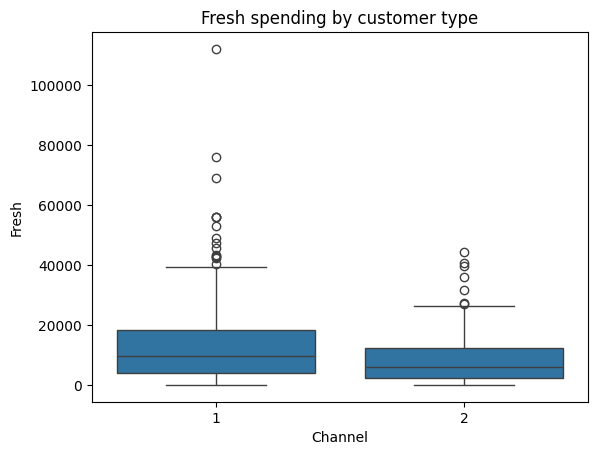

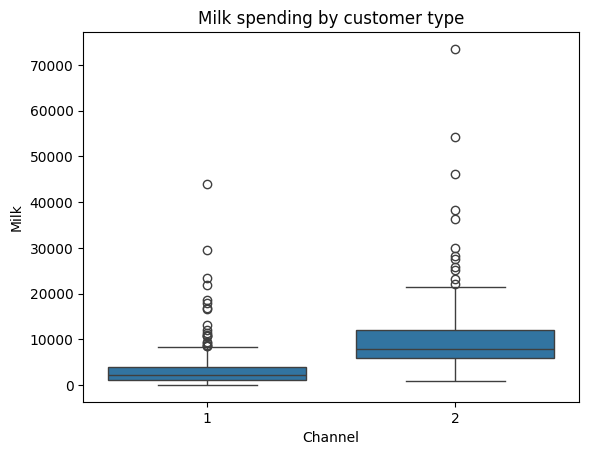

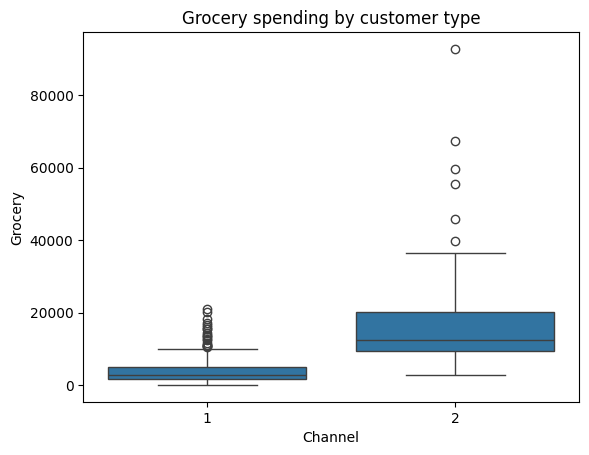

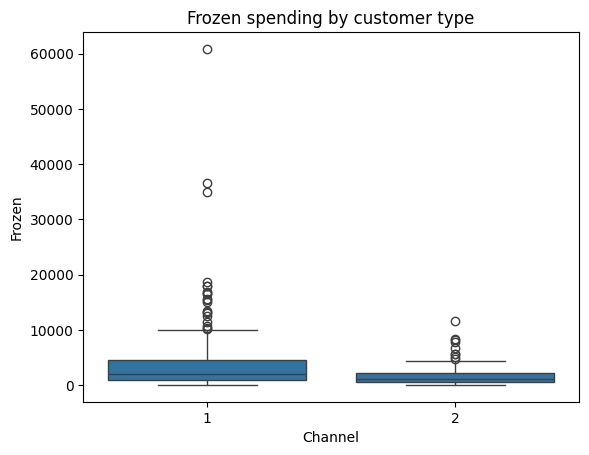

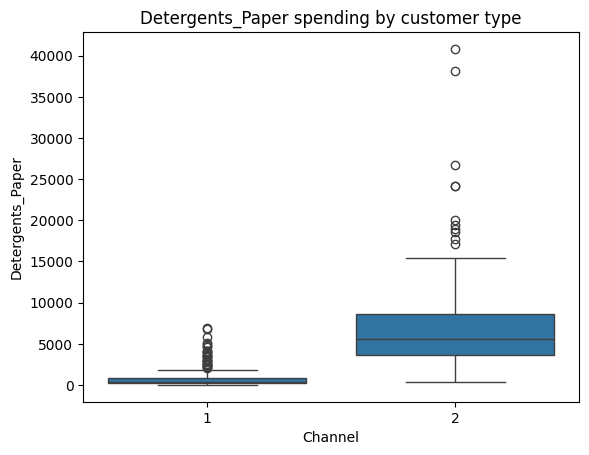

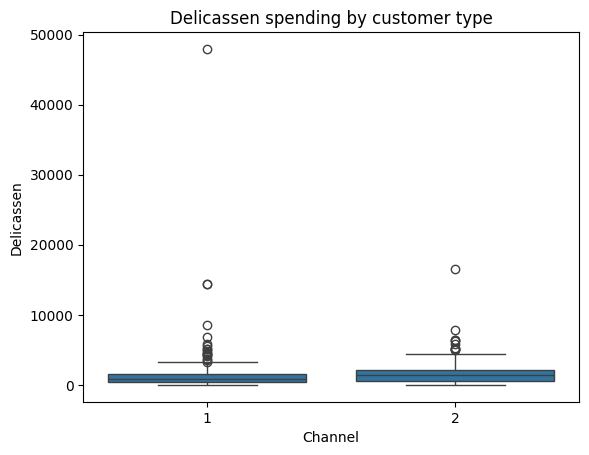

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("Wholesale customers data.csv")
features = ['Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']
for feature in features:
    plt.figure()
    sns.boxplot(x='Channel', y=feature, data=df)
    plt.title(f'{feature} spending by customer type')
    plt.show()

# **4) Model Selection**

**Decision Tree Classifier**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,recall_score,precision_score
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25)
model=DecisionTreeClassifier()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print("accuracy is",accuracy_score(y_pred,y_test))
print("recall is " ,recall_score(y_pred,y_test))
print("precision is",precision_score(y_pred,y_test))

accuracy is 0.8272727272727273
recall is  0.9117647058823529
precision is 0.8266666666666667


**Random Forest Classifier**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=50,random_state=42)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print("accuracy is ", accuracy_score(y_pred,y_test))

accuracy is  0.8818181818181818


# **5) Model Training & Validation**

**i)	Split the dataset into training and testing sets.**

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

# **6) Model Evaluation**

i)	Evaluate models using metrics such as Accuracy, Precision, Recall, F1-score, and Confusion Matrix.

# **Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
scaled = StandardScaler()
X_train_scaled = scaled.fit_transform(X_train)
X_test_scaled = scaled.transform(X_test)
model = LogisticRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9
              precision    recall  f1-score   support

           1       0.92      0.94      0.93        78
           2       0.84      0.81      0.83        32

    accuracy                           0.90       110
   macro avg       0.88      0.87      0.88       110
weighted avg       0.90      0.90      0.90       110

